In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`
Precompiling packages...
   4723.7 ms  ✓ CausalSetZoology
  1 dependency successfully precompiled in 15 seconds. 418 already precompiled.


In [2]:
using Revise
using Statistics
using CairoMakie
includet("analysis.jl")

In [3]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [4]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

In [7]:
candidates = [
    "/Volumes/Causal Set Silo/causal_sets/analysis/",
    "/Volumes/Causal Set Silochen/causal_sets/analysis/",
]

root_path = let p = findfirst(isdir, candidates)
    p === nothing && error("No analysis path found")
    candidates[p]
end

data_path_man = [joinpath(root_path,"manifoldlike_simply_connected_2048_10000/statistics.jld2")]

function data_paths(file_names::Vector{String})::Vector{String}
    return [joinpath(root_path, file_name) for file_name in file_names]
end

data_paths (generic function with 1 method)

In [198]:
data_paths_single = data_paths([
    "manifoldlike_simply_connected_2048_10000/statistics.jld2",
    "minkowski_sprinkling_2048_10000/statistics.jld2",
    "grid_2048_10000/statistics.jld2",
    "minkowski_quasicrystal_2048_10000/statistics.jld2",
    "layered_2048_10000/statistics.jld2",
    "random_2048_10000/statistics.jld2",
])

data_paths_non_manifoldlikeness = data_paths([
    "destroyed_2048_30000/statistics.jld2",
    "merged_link_prob_tenth_2048_30000/statistics.jld2",
    "manifoldlike_genus_2048_10000/statistics.jld2",
    "manifoldlike_pants_2048_10000/statistics.jld2",
])

data_paths_non_manifoldlikeness_2 = data_paths([
    "destroyed_2048_100000/statistics.jld2"
])

data_paths_non_manifoldlikeness_3 = data_paths([
    "destroyed_2048_4000/statistics.jld2"
])

1-element Vector{String}:
 "/Volumes/Causal Set Silo/causal" ⋯ 19 bytes ⋯ "royed_2048_4000/statistics.jld2"

In [175]:
function group_histograms_by_scalar(
    hist_scalar_pairs::AbstractVector{<:Tuple{<:AbstractDict,<:Real}};
    integer_scalar::Bool = false,
)
    grouped = Dict{Float64, Vector{Dict}}()
    for (hist, scalar) in hist_scalar_pairs
        key = integer_scalar ? Float64(round(Int, scalar)) : Float64(scalar)
        push!(get!(grouped, key, Dict[]), hist)
    end
    return grouped
end

function group_histograms_by_scalar(
    hist_scalar_pairs::AbstractVector{<:Tuple{<:AbstractVector,<:Real}};
    integer_scalar::Bool = false,
)
    grouped = Dict{Float64, Vector{Vector{Float64}}}()
    for (hist, scalar) in hist_scalar_pairs
        key = integer_scalar ? Float64(round(Int, scalar)) : Float64(scalar)
        push!(get!(grouped, key, Vector{Float64}[]), Float64.(hist))
    end
    return grouped
end

group_histograms_by_scalar (generic function with 3 methods)

# Degree distribution

In [17]:
degrees_single_dicts = normalize_hists(load_histograms_from_paths(data_paths_single, :degree_hist_link));
degrees_single = [densify_hists_vectors(hist_ensemble) for hist_ensemble in degrees_single_dicts]

6-element Vector{Vector{Vector{Float64}}}:
 [[0.00048828125, 0.0009765625, 0.0029296875, 0.00927734375, 0.017578125, 0.02734375, 0.044921875, 0.05810546875, 0.0869140625, 0.10009765625  …  0.0, 0.0, 0.0, 0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.00048828125, 0.001953125, 0.00341796875, 0.01513671875, 0.02783203125, 0.046875, 0.0673828125, 0.09228515625, 0.10302734375  …  0.0, 0.0, 0.0, 0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.001953125, 0.00927734375, 0.01318359375, 0.029296875, 0.05078125, 0.080078125, 0.08447265625, 0.10400390625  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.00048828125, 0.0029296875, 0.0068359375, 0.01708984375, 0.02880859375, 0.03466796875, 0.0625, 0.0859375, 0.0947265625  …  0.0009765625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.00048828125, 0.001953125, 0.0068359375, 0.01708984375, 0.021484375, 0.04052734375, 0.064453125, 0.0859375, 0.10791015625, 0.11328125  …  0.0, 0.00048828125, 0.00048828125, 0.0, 0.0, 0.

In [143]:
degrees_non_manifoldlikeness_dicts = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :degree_hist_link, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness)];
degrees_non_manifoldlikeness = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness_dicts]

4-element Vector{Dict{Float64, Vector{Vector{Float64}}}}:
 Dict(0.02446987970200293 => [[0.00048828125, 0.0146484375, 0.037109375, 0.06689453125, 0.10791015625, 0.13671875, 0.15234375, 0.16162109375, 0.1279296875, 0.07958984375  …  0.01611328125, 0.00537109375, 0.00146484375, 0.0, 0.0, 0.00048828125, 0.0, 0.0, 0.0, 0.0], [0.0009765625, 0.0068359375, 0.0224609375, 0.0439453125, 0.06982421875, 0.10205078125, 0.142578125, 0.14892578125, 0.13916015625, 0.126953125  …  0.029296875, 0.01513671875, 0.01025390625, 0.001953125, 0.00146484375, 0.0, 0.0, 0.0, 0.0, 0.0], [0.001953125, 0.00830078125, 0.0263671875, 0.04833984375, 0.0791015625, 0.111328125, 0.130859375, 0.1533203125, 0.146484375, 0.1103515625  …  0.02880859375, 0.017578125, 0.0068359375, 0.00341796875, 0.0009765625, 0.00048828125, 0.0009765625, 0.0, 0.0, 0.0], [0.00048828125, 0.015625, 0.03271484375, 0.05078125, 0.07958984375, 0.1103515625, 0.14453125, 0.15087890625, 0.125, 0.1123046875  …  0.0263671875, 0.015625, 0.00537109375, 0.00

In [ ]:
degrees_non_manifoldlikeness_dicts_2 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :degree_hist_link, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_2)];
degrees_non_manifoldlikeness_2 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness_dicts_2]

degrees_non_manifoldlikeness_dicts_3 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :degree_hist_link, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_3)];
degrees_non_manifoldlikeness_3 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness_dicts_3]

1-element Vector{Dict{Float64, Vector{Vector{Float64}}}}:
 Dict(3.339490718124084e-6 => [[0.0, 0.001953125, 0.00341796875, 0.005859375, 0.02294921875, 0.037109375, 0.046875, 0.0859375, 0.0859375, 0.12109375  …  0.0009765625, 0.00048828125, 0.00048828125, 0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.00048828125, 0.0, 0.00390625, 0.0078125, 0.0166015625, 0.0263671875, 0.04345703125, 0.068359375, 0.08349609375, 0.111328125  …  0.00048828125, 0.0, 0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0009765625, 0.00439453125, 0.0078125, 0.021484375, 0.02685546875, 0.0478515625, 0.078125, 0.0947265625, 0.1103515625  …  0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.00048828125, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0009765625, 0.005859375, 0.01708984375, 0.03076171875, 0.05859375, 0.0712890625, 0.08154296875, 0.1015625, 0.1044921875  …  0.0009765625, 0.0, 0.00048828125, 0.00048828125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.00146484375, 0.0029296875, 0.01611328125, 0.02294921875, 0.0390625, 0.0644531

## Null distribution

In [24]:
degree_null_man = null_distance_percentile(CausalSetZoology.total_variation_distance, degrees_single[1]; percentile = 1/2)
degree_null_mink = null_distance_percentile(CausalSetZoology.total_variation_distance, degrees_single[2]; percentile = 1/2)

0.05078125

## Grid

In [93]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, degrees_single[1], degrees_single[3]; null_value = degree_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.665278932915039, std_between = 0.20607802851895243, std_lo = 0.22973205791503903, std_up = 0.24634216083496097)

## Quasicrystal

In [94]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, degrees_single[2], degrees_single[4]; null_value = degree_null_mink)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05078125, percentile = 0.5, mean_between = 0.48280392984375, std_between = 0.016772022384024202, std_lo = 0.01649533609374998, std_up = 0.01670778890625002)

## Layered

In [95]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, degrees_single[1], degrees_single[5]; null_value = degree_null_man)

(D = 0.99961134, probability_below_null = 0.00038866, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.9458642113574218, std_between = 0.1531101566223244, std_lo = 0.007387648857421825, std_up = 0.054135788642578175)

## Random

In [97]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, degrees_single[1], degrees_single[6]; null_value = degree_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.4037901932861328, std_between = 0.043376180195789975, std_lo = 0.037090974536132804, std_up = 0.039080900463867196)

## Non-manifoldlikeness

In [144]:
degrees_non_manifoldlikeness_prob = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, degrees_single[1]; null_value = degree_null_man))
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness]

4-element Vector{Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}:
 Dict(0.02446987970200293 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.45006041457877793, std_between = 0.044116428043316, std_lo = 0.037462758328777934, std_up = 0.039197397921222066), 0.012964857107962873 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.3945975614535317, std_between = 0.043851805538745944, std_lo = 0.0376639677035317, std_up = 0.0380196260464683), 0.033617221849047384 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.48912941224806966, std_between = 0.04068092498872562, std_lo = 0.03405128724806966, std_up = 0.03626121275193034), 0.009437400769418661 => (D = 1.0, probability_below_null = 

In [ ]:
degrees_non_manifoldlikeness_prob_2 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, degrees_single[1]; null_value = degree_null_man))
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness_2]

degrees_non_manifoldlikeness_prob_3 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, degrees_single[1]; null_value = degree_null_man))
    for (s, hs) in classes
) for classes in degrees_non_manifoldlikeness_3]

degree_destroyed_all = merge(
    degrees_non_manifoldlikeness_prob[1],
    degrees_non_manifoldlikeness_prob_2[1],
    degrees_non_manifoldlikeness_prob_3[1]
)

1-element Vector{Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}:
 Dict(3.339490718124084e-6 => (D = 0.5258888125613346, probability_below_null = 0.47411118743866537, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.06781121537467799, std_between = 0.027392357659808887, std_lo = 0.02044793412467799, std_up = 0.01812628462532201), 1.0018472154372252e-5 => (D = 0.5986226600985222, probability_below_null = 0.40137733990147784, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.07160162109375, std_between = 0.029702584536697288, std_lo = 0.022285214843749998, std_up = 0.020195253906250002), 1.4312103077674645e-6 => (D = 0.5166385685884691, probability_below_null = 0.4833614314115308, null_value = 0.05908203125, percentile = 0.5, mean_between = 0.06676852673024354, std_between = 0.026123463713520954, std_lo = 0.0198935267

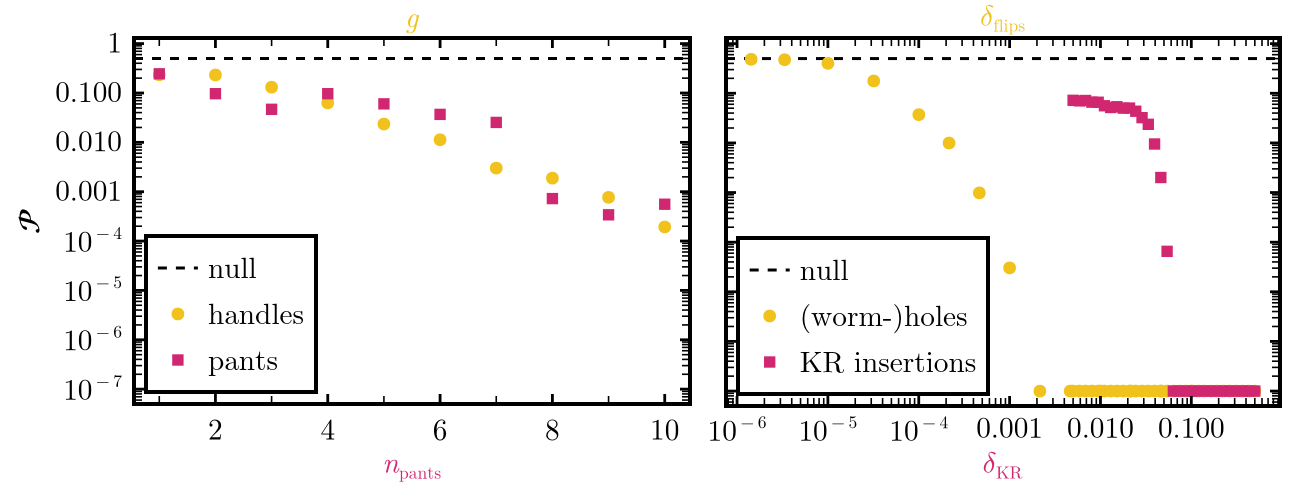

In [217]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y = true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    ["handles", "pants"],
    ["(worm-)holes", "KR insertions"],
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

result_by_name = Dict(
    "(worm-)holes" => degree_destroyed_all,
    "KR insertions" => degrees_non_manifoldlikeness_prob[2],
    "handles" => degrees_non_manifoldlikeness_prob[3],
    "pants" => degrees_non_manifoldlikeness_prob[4],
)

for (idx, names) in enumerate(group_specs)
    gl = GridLayout(fig_prob_grouped[1, idx])

    top_text, top_color =
        idx == 1 ? (L"g", col["handles"]) : (L"\delta_{\text{flips}}", col["(worm-)holes"])
    bottom_text, bottom_color =
        idx == 1 ? (L"n_{\text{pants}}", col["pants"]) : (L"\delta_{\text{KR}}", col["KR insertions"])

    Label(gl[1, 1], top_text; color = top_color, tellwidth = false)

    idx == 2 && apply_paper_theme!(; magnification = 1.0, logscale_y = true, logscale_x = true)

    ax = Axis(
        gl[2, 1];
        xlabel = "",
        ylabel = idx == 1 ? L"\mathcal{P}" : "",
        yscale = log10,
        xscale = idx == 2 ? log10 : identity,
        yticklabelsvisible = idx == 1,
    )

    Label(gl[3, 1], bottom_text; color = bottom_color, tellwidth = false)

    rowsize!(gl, 1, Fixed(18))
    rowsize!(gl, 2, Relative(0.9))
    rowsize!(gl, 3, Fixed(22))
    rowgap!(gl, 0.5)

    ylims!(ax, 0.5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash, label = "null")

    for name in names
        result = result_by_name[name]
        xs = sort(collect(keys(result)))
        probs = [result[x].probability_below_null === 0. ? 1e-7 : result[x].probability_below_null for x in xs]

        scatter!(
            ax,
            xs,
            probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end

    axislegend(ax; position = [:lb, :lb][idx])
end

save(fig_path("graph_observables/degree_probabilities_panel.pdf"), fig_prob_grouped)

fig_prob_grouped


# Interval abundances

In [ ]:
cardinalities_single_dicts = normalize_hists(load_histograms_from_paths(data_paths_single, :cardinalities_hist));
cardinalities_single = [densify_hists_vectors(hist_ensemble) for hist_ensemble in cardinalities_single_dicts]

6-element Vector{Vector{Vector{Float64}}}:
 [[0.0019849461990412553, 0.0120182289395076, 0.00988014724268875, 0.008953580559933163, 0.008372053353182795, 0.007848678867107464, 0.007559853687754782, 0.006977357268993163, 0.006875590007811848, 0.0067088855418767435  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.002289508839985914, 0.013652090797806632, 0.011498968714890192, 0.010171992644058513, 0.009566077706913803, 0.009353672101641671, 0.008794709982504485, 0.00828717237832792, 0.008098243182059551, 0.007782988546866179  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.001925336792922883, 0.011357418845361988, 0.009649246505156481, 0.008620770698780682, 0.007994660198738377, 0.0075358885410497225, 0.007241635408146957, 0.006841150313525303, 0.006725517293247219, 0.006582621203147474  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.001996784475000707, 0.012147430553727445, 0.009978072420486931, 0.008997230046536388, 0.008223086065505841, 0.007879888733865094

In [139]:
cardinalities_non_manifoldlikeness_dicts = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :cardinalities_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness)];
cardinalities_non_manifoldlikeness = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness_dicts]

4-element Vector{Dict{Float64, Vector{Vector{Float64}}}}:
 Dict(0.02446987970200293 => [[0.0010338614878013935, 0.0038431579622226607, 0.005523687695079516, 0.005850303116274585, 0.00526724158384753, 0.004469633600094502, 0.003846186853300204, 0.0034877680757909317, 0.003194470456448837, 0.0028905717183353415  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0010571981358623494, 0.00439243112209606, 0.0072305538520624655, 0.008196382813096868, 0.0072553319333717396, 0.005985455266271456, 0.005125965570856021, 0.0045147728985606, 0.0040321165230570374, 0.00367231813404529  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0010563670875629282, 0.004311607658661384, 0.0069777997854254354, 0.007958859453660146, 0.007173289593133614, 0.005981265989931501, 0.0050048485598745565, 0.004497297185772056, 0.004050610712222498, 0.003624040604109928  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0010510568304580668, 0.004199095208402296, 0.0066358226649525405, 0.0075431803

In [219]:
cardinalities_non_manifoldlikeness_dicts_2 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :cardinalities_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_2)];
cardinalities_non_manifoldlikeness_2 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness_dicts_2]

cardinalities_non_manifoldlikeness_dicts_3 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :cardinalities_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_3)];
cardinalities_non_manifoldlikeness_3 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness_dicts_3]

1-element Vector{Dict{Float64, Vector{Vector{Float64}}}}:
 Dict(3.339490718124084e-6 => [[0.002086293924993251, 0.011979890897422183, 0.010119747974063944, 0.009344518639630416, 0.008676252616781016, 0.008145510851682634, 0.008071145882676527, 0.007444646486255214, 0.0073733376118657965, 0.007110513474830514  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0018924605591075126, 0.011130218473852534, 0.009217428748582734, 0.008572439749433787, 0.007912665902166813, 0.007416449437205516, 0.0070994992556753025, 0.006770536385049192, 0.006611599267780397, 0.006545067451249273  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0018237044174074723, 0.010538838759774138, 0.009041940749197008, 0.007971582980777193, 0.007626966960495606, 0.007088226153595449, 0.006752514940039484, 0.0066020237063764645, 0.006381184499581029, 0.006100683087723923  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0018277750408750473, 0.010098278607178301, 0.008238374708162872, 0.00738695996

## Null distribution

In [29]:
cardinalities_null_man = null_distance_percentile(CausalSetZoology.total_variation_distance, cardinalities_single[1]; percentile = 1/2)
cardinalities_null_mink = null_distance_percentile(CausalSetZoology.total_variation_distance, cardinalities_single[2]; percentile = 1/2)

0.017984075935902465

## Grid

In [96]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, cardinalities_single[1], cardinalities_single[3]; null_value = cardinalities_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.40094975675520705, std_between = 0.16080518934218668, std_lo = 0.1501347627821108, std_up = 0.17246278269870619)

## Quasicrystal

In [98]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, cardinalities_single[2], cardinalities_single[4]; null_value = cardinalities_null_mink)

(D = 1.0, probability_below_null = 0.0, null_value = 0.017984075935902465, percentile = 0.5, mean_between = 0.06944454363607211, std_between = 0.0034796533426858897, std_lo = 0.003438775386685272, std_up = 0.003502938593621413)

## Layered

In [99]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, cardinalities_single[1], cardinalities_single[5]; null_value = cardinalities_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.6094530543186885, std_between = 0.17676123393568072, std_lo = 0.1642917260951967, std_up = 0.19148455158991817)

## Random

In [100]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, cardinalities_single[1], cardinalities_single[6]; null_value = cardinalities_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.22691856714961603, std_between = 0.030127407193875886, std_lo = 0.024625247222146956, std_up = 0.022822900416499398)

## Non-manifoldlikeness

In [ ]:
cardinalities_non_manifoldlikeness_prob = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, cardinalities_single[1]; null_value = cardinalities_null_man))
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness]

4-element Vector{Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}:
 Dict(0.02446987970200293 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.4082141965911561, std_between = 0.05496167843715938, std_lo = 0.044160822160798974, std_up = 0.03683685021917693), 0.012964857107962873 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.37796978502643586, std_between = 0.053710810641864705, std_lo = 0.04335813397490401, std_up = 0.03708491431430716), 0.033617221849047384 => (D = 1.0, probability_below_null = 0.0, null_value = 0.05240206854373507, percentile = 0.5, mean_between = 0.42194054940468767, std_between = 0.05517432344033435, std_lo = 0.04401507705682545, std_up = 0.03592481460274127), 0.009437400769418661 => (D = 1.0, prob

In [ ]:
cardinalities_non_manifoldlikeness_prob_2 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, cardinalities_single[1]; null_value = cardinalities_null_man))
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness_2]

cardinalities_non_manifoldlikeness_prob_3 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, cardinalities_single[1]; null_value = cardinalities_null_man))
    for (s, hs) in classes
) for classes in cardinalities_non_manifoldlikeness_3]

cardinalities_destroyed_all = merge(
    cardinalities_non_manifoldlikeness_prob[1],
    cardinalities_non_manifoldlikeness_prob_2[1],
    cardinalities_non_manifoldlikeness_prob_3[1]
)

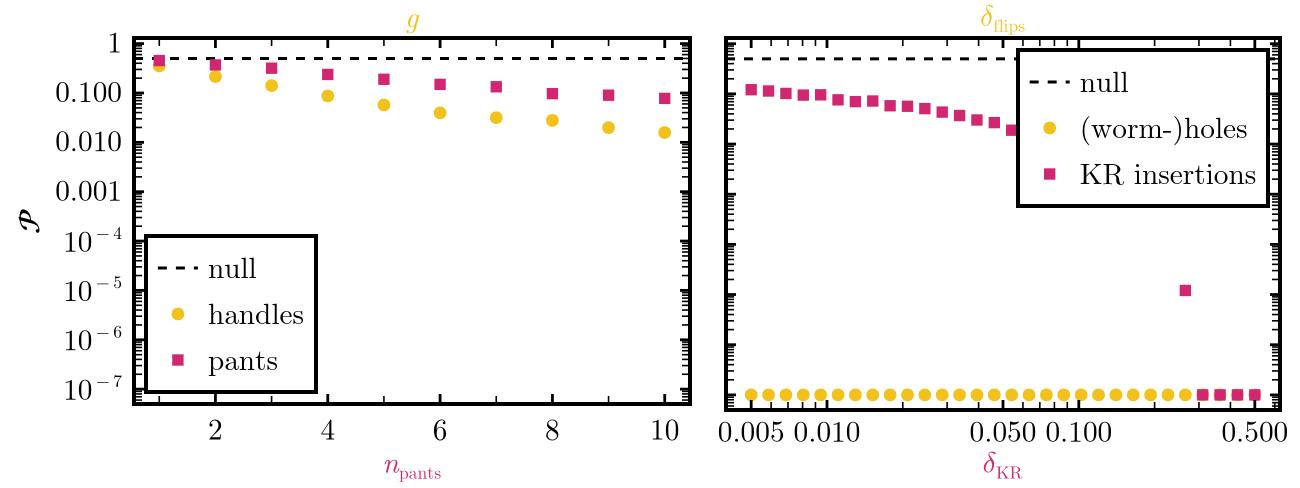

In [ ]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y = true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    ["handles", "pants"],
    ["(worm-)holes", "KR insertions"],
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

result_by_name = Dict(
    "(worm-)holes" => cardinalities_destroyed_all,
    "KR insertions" => cardinalities_non_manifoldlikeness_prob[2],
    "handles" => cardinalities_non_manifoldlikeness_prob[3],
    "pants" => cardinalities_non_manifoldlikeness_prob[4],
)

for (idx, names) in enumerate(group_specs)
    gl = GridLayout(fig_prob_grouped[1, idx])

    top_text, top_color =
        idx == 1 ? (L"g", col["handles"]) : (L"\delta_{\text{flips}}", col["(worm-)holes"])
    bottom_text, bottom_color =
        idx == 1 ? (L"n_{\text{pants}}", col["pants"]) : (L"\delta_{\text{KR}}", col["KR insertions"])

    Label(gl[1, 1], top_text; color = top_color, tellwidth = false)

    idx == 2 && apply_paper_theme!(; magnification = 1.0, logscale_y = true, logscale_x = true)

    ax = Axis(
        gl[2, 1];
        xlabel = "",
        ylabel = idx == 1 ? L"\mathcal{P}" : "",
        yscale = log10,
        xscale = idx == 2 ? log10 : identity,
        yticklabelsvisible = idx == 1,
    )

    Label(gl[3, 1], bottom_text; color = bottom_color, tellwidth = false)

    rowsize!(gl, 1, Fixed(18))
    rowsize!(gl, 2, Relative(0.9))
    rowsize!(gl, 3, Fixed(22))
    rowgap!(gl, 0.5)

    ylims!(ax, 0.5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash, label = "null")

    for name in names
        result = result_by_name[name]
        xs = sort(collect(keys(result)))
        probs = [result[x].probability_below_null === 0. ? 1e-7 : result[x].probability_below_null for x in xs]

        scatter!(
            ax,
            xs,
            probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end

    axislegend(ax; position = [:lb, :rt][idx])
end

save(fig_path("graph_observables/cardinalities_probabilities_panel.pdf"), fig_prob_grouped)

fig_prob_grouped

# Laplacian Eigenvalues

In [77]:
evs_single_before_conversion = load_fields_from_paths(data_paths_single, [:ev_sym_link]);
evs_single =[evs_ensemble[1] for evs_ensemble in evs_single_before_conversion]

6-element Vector{Vector{Vector{Float64}}}:
 [[8.881784197001252e-16, 0.10893025622275776, 0.1532979539348556, 0.16375380877660203, 0.18928551944166816, 0.22502820259293105, 0.22675283033543975, 0.24458394878843126, 0.25645192353269175, 0.2760260395634402  …  1.6162947874149638, 1.6190716286350244, 1.6208211373937007, 1.623144796865189, 1.626267145539384, 1.6312833029203746, 1.6332006666857437, 1.639074671856125, 1.6442301048443428, 1.6622992245928458], [1.1102230246251565e-16, 0.10000992215998439, 0.1563722826536066, 0.16451171800042275, 0.18232592262335623, 0.20791810613046824, 0.23147715277438008, 0.24651313912468287, 0.26236122645233784, 0.27144400398622404  …  1.6141367501722095, 1.6152298437811525, 1.617251915319087, 1.6228747051083863, 1.627174417301326, 1.6289148860088594, 1.6376800560282447, 1.6383178688852469, 1.6447509056337228, 1.661640913514152], [2.220446049250313e-16, 0.09098523239532497, 0.14434104882987292, 0.15113808855764038, 0.20635295737988757, 0.21171330871638128, 

In [177]:
evs_non_manifoldlikeness = [group_histograms_by_scalar(load_fields_from_paths([path], [:ev_sym_link], (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i])[1][1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness)];

In [ ]:
evs_non_manifoldlikeness_2 = [group_histograms_by_scalar(load_fields_from_paths([path], [:ev_sym_link], (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i])[1][1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_2)];

In [199]:
evs_non_manifoldlikeness_3 = [group_histograms_by_scalar(load_fields_from_paths([path], [:ev_sym_link], (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i])[1][1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_3)];

## Null distribution

In [64]:
evs_null_man = null_distance_percentile(CausalSetZoology.total_variation_distance, evs_single[1]; percentile = 1/2)
evs_null_mink = null_distance_percentile(CausalSetZoology.total_variation_distance, evs_single[2]; percentile = 1/2)

1.7309038458449475

## Grid

In [101]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, evs_single[1], evs_single[3]; null_value = evs_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 81.6426247985337, std_between = 47.3106940408415, std_lo = 50.19354802881214, std_up = 54.083270200359394)

## Quasicrystals

In [102]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, evs_single[2], evs_single[4]; null_value = evs_null_mink)

(D = 1.0, probability_below_null = 0.0, null_value = 1.7309038458449475, percentile = 0.5, mean_between = 46.965156540379915, std_between = 1.5919183705918682, std_lo = 1.5767711498041308, std_up = 1.5636641076378837)

## Layered

In [103]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, evs_single[1], evs_single[5]; null_value = evs_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 181.20272730863024, std_between = 49.71470380625718, std_lo = 45.59543446863552, std_up = 42.59651040241755)

## Random

In [104]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, evs_single[1], evs_single[6]; null_value = evs_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 85.33600503329747, std_between = 6.6159467948447706, std_lo = 6.137596098700925, std_up = 6.259441908320653)

## Non-manifoldlikeness

In [178]:
evs_non_manifoldlikeness_prob = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, evs_single[1]; null_value = evs_null_man))
    for (s, hs) in classes
) for classes in evs_non_manifoldlikeness]

4-element Vector{Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}:
 Dict(0.02446987970200293 => (D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 67.16785374071061, std_between = 5.092575133978763, std_lo = 4.4784370335434645, std_up = 4.593163645795627), 0.012964857107962873 => (D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 53.63880488424701, std_between = 4.861413560072907, std_lo = 4.280439024473694, std_up = 4.315425034038697), 0.033617221849047384 => (D = 1.0, probability_below_null = 0.0, null_value = 2.918186992747458, percentile = 0.5, mean_between = 76.22008760247944, std_between = 4.797500261386328, std_lo = 4.2561456343623405, std_up = 4.418094882643757), 0.017811412280166097 => (D = 1.0, probability_below_null = 0.0, nul

In [ ]:
evs_non_manifoldlikeness_prob_2 = [
    [(s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, evs_single[1]; null_value = evs_null_man))
    for (s, hs) in classes]
 for classes in evs_non_manifoldlikeness_2]

In [200]:
evs_non_manifoldlikeness_prob_3 = [
    [(s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, evs_single[1]; null_value = evs_null_man))
    for (s, hs) in classes]
 for classes in evs_non_manifoldlikeness_3]

1-element Vector{Vector{Tuple{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}}:
 [(3.339490718124084e-6, (D = 0.5392400392541707, probability_below_null = 0.46075996074582926, null_value = 2.918186992747458, percentile = 0.5, mean_between = 4.320473202778769, std_between = 3.451140616744805, std_lo = 2.7881541753157606, std_up = 2.948415873550828)), (1.0018472154372252e-5, (D = 0.6542773399014779, probability_below_null = 0.34572266009852215, null_value = 2.918186992747458, percentile = 0.5, mean_between = 5.08633629830991, std_between = 3.8330871494831, std_lo = 3.1627725796696504, std_up = 3.1092939617365447)), (1.4312103077674645e-6, (D = 0.5201015904572565, probability_below_null = 0.47989840954274354, null_value = 2.918186992747458, percentile = 0.5, mean_between = 4.1539998898599375, std_between = 3.3570244536264595, std_lo = 2.7028193737089

In [201]:
destroyed_extra = Dict(evs_non_manifoldlikeness_prob_2[1])
destroyed_extra_2 = Dict(evs_non_manifoldlikeness_prob_3[1])

destroyed_all = merge(
    evs_non_manifoldlikeness_prob[1],
    destroyed_extra,
    destroyed_extra_2
)

Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}} with 44 entries:
  0.0244699   => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.0129649   => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.0100003   => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.363948    => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.0110613   => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.1         => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.00100042  => (D = 0.999911, probability_below_null = 8.91675e-5, null_value…
  0.0208771   => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.119752    => (D = 1.0, probability_below_null = 0.0, null_value = 2.91819, …
  0.5         => (D = 1.0, probability_below_null = 0.0, null

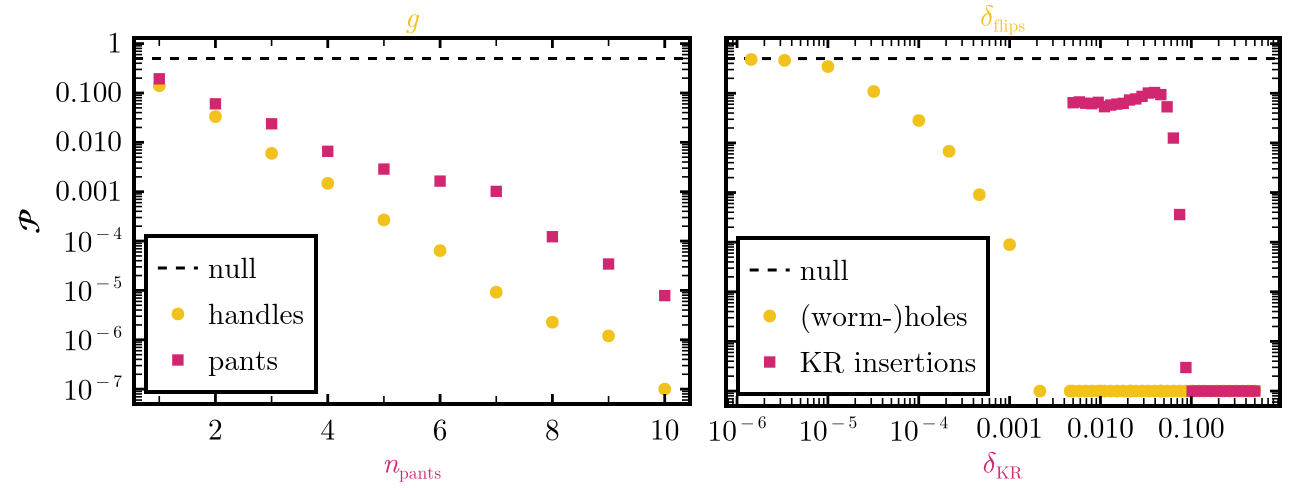

In [205]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y = true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    ["handles", "pants"],
    ["(worm-)holes", "KR insertions"],
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

result_by_name = Dict(
    "(worm-)holes" => destroyed_all,
    "KR insertions" => evs_non_manifoldlikeness_prob[2],
    "handles" => evs_non_manifoldlikeness_prob[3],
    "pants" => evs_non_manifoldlikeness_prob[4],
)

for (idx, names) in enumerate(group_specs)
    gl = GridLayout(fig_prob_grouped[1, idx])

    top_text, top_color =
        idx == 1 ? (L"g", col["handles"]) : (L"\delta_{\text{flips}}", col["(worm-)holes"])
    bottom_text, bottom_color =
        idx == 1 ? (L"n_{\text{pants}}", col["pants"]) : (L"\delta_{\text{KR}}", col["KR insertions"])

    Label(gl[1, 1], top_text; color = top_color, tellwidth = false)

    idx == 2 && apply_paper_theme!(; magnification = 1.0, logscale_y = true, logscale_x = true)

    ax = Axis(
        gl[2, 1];
        xlabel = "",
        ylabel = idx == 1 ? L"\mathcal{P}" : "",
        yscale = log10,
        xscale = idx == 2 ? log10 : identity,
        yticklabelsvisible = idx == 1,
    )

    Label(gl[3, 1], bottom_text; color = bottom_color, tellwidth = false)

    rowsize!(gl, 1, Fixed(18))
    rowsize!(gl, 2, Relative(0.9))
    rowsize!(gl, 3, Fixed(22))
    rowgap!(gl, 0.5)

    ylims!(ax, 0.5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash, label = "null")

    for name in names
        result = result_by_name[name]
        xs = sort(collect(keys(result)))
        probs = [result[x].probability_below_null < 1e-7 ? 1e-7 : result[x].probability_below_null for x in xs]

        scatter!(
            ax,
            xs,
            probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end
    axislegend(ax; position = [:lb, :lb][idx])
end

save(fig_path("graph_observables/evs_probabilities_panel.pdf"), fig_prob_grouped)

fig_prob_grouped

# Height distribution

In [82]:
height_single_dicts = normalize_hists(load_histograms_from_paths(data_paths_single, :max_pathlen_hist));
height_single = [densify_hists_vectors(hist_ensemble) for hist_ensemble in height_single_dicts]

6-element Vector{Vector{Vector{Float64}}}:
 [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0,

In [163]:
height_non_manifoldlikeness_dicts = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :max_pathlen_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness)];
height_non_manifoldlikeness = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness_dicts]

4-element Vector{Dict{Float64, Vector{Vector{Float64}}}}:
 Dict(0.02446987970200293 => [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0

In [ ]:
height_non_manifoldlikeness_dicts_2 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :max_pathlen_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_2)];
height_non_manifoldlikeness_2 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness_dicts_2]

height_non_manifoldlikeness_dicts_3 = [group_histograms_by_scalar(normalize_hists(load_histograms_from_paths([path], :max_pathlen_hist, (:rel_num_flips, :rel_size_KR, :genus, :num_boundary_cuts)[i]))[1]) for (i, path) in enumerate(data_paths_non_manifoldlikeness_3)];
height_non_manifoldlikeness_3 = [Dict(
    s => CausalSetZoology.densify_hists_vectors(hs)
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness_dicts_3]

## Null distribution

In [83]:
height_null_man = null_distance_percentile(CausalSetZoology.total_variation_distance, height_single[1]; percentile = 1/2)
height_null_mink = null_distance_percentile(CausalSetZoology.total_variation_distance, height_single[2]; percentile = 1/2)

0.875

## Grids

In [105]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, height_single[1], height_single[3]; null_value = height_null_man)

(D = 0.92052273, probability_below_null = 0.07947727, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 0.9409550763345519, std_between = 0.10037188584088032, std_lo = 0.10422038245700083, std_up = 0.05904492366544811)

## Quasicrystals

In [106]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, height_single[2], height_single[4]; null_value = height_null_mink)

(D = 0.68389817, probability_below_null = 0.31610183, null_value = 0.875, percentile = 0.5, mean_between = 0.929690693404059, std_between = 0.09373477876717214, std_lo = 0.0963573600707257, std_up = 0.07030930659594103)

## Layered

In [107]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, height_single[1], height_single[5]; null_value = height_null_man)

(D = 1.0, probability_below_null = 0.0, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 0.9999732030504468, std_between = 0.0009294212791175076, std_lo = -2.6796949553098415e-5, std_up = 2.6796949553209437e-5)

## Random

In [108]:
CausalSetZoology.distance_distinguishability_probability(CausalSetZoology.total_variation_distance, height_single[1], height_single[6]; null_value = height_null_man)

(D = 0.59673467, probability_below_null = 0.40326533, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 0.7872078276642885, std_between = 0.18774752392675217, std_lo = 0.21492113824449333, std_up = 0.20313033658691915)

## Non-manifoldlikeness

In [164]:
height_non_manifoldlikeness_prob = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, height_single[1]; null_value = height_null_man))
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness]

4-element Vector{Dict{Float64, @NamedTuple{D::Float64, probability_below_null::Float64, null_value::Float64, percentile::Float64, mean_between::Float64, std_between::Float64, std_lo::Float64, std_up::Float64}}}:
 Dict(0.02446987970200293 => (D = 1.0, probability_below_null = 0.0, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 1.0, std_between = 0.0, std_lo = 0.0, std_up = 0.0), 0.012964857107962873 => (D = 0.999930694143167, probability_below_null = 6.93058568329718e-5, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 0.9999068680635739, std_between = 0.003947572438589691, std_lo = -9.313193642612738e-5, std_up = 9.313193642612738e-5), 0.033617221849047384 => (D = 1.0, probability_below_null = 0.0, null_value = 0.7622996130458817, percentile = 0.5, mean_between = 1.0, std_between = 0.0, std_lo = 0.0, std_up = 0.0), 0.009437400769418661 => (D = 0.9994064859632139, probability_below_null = 0.00059351403678606, null_value = 0.7622996130458817, percentil

In [ ]:
height_non_manifoldlikeness_prob_2 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, height_single[1]; null_value = height_null_man))
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness_2]

height_non_manifoldlikeness_prob_3 = [Dict(
    (s, distance_distinguishability_probability(CausalSetZoology.total_variation_distance, hs, height_single[1]; null_value = height_null_man))
    for (s, hs) in classes
) for classes in height_non_manifoldlikeness_3]

height_destroyed_all = merge(
    height_non_manifoldlikeness_prob[1],
    height_non_manifoldlikeness_prob_2[1],
    height_non_manifoldlikeness_prob_3[1]
)

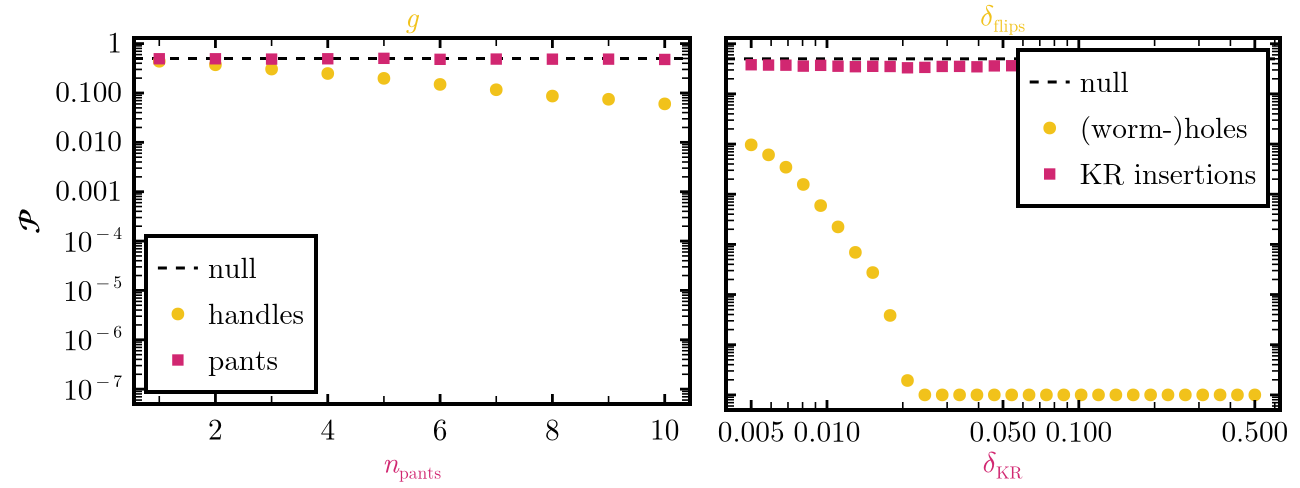

In [ ]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y = true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    ["handles", "pants"],
    ["(worm-)holes", "KR insertions"],
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

result_by_name = Dict(
    "(worm-)holes" => height_destroyed_all,
    "KR insertions" => height_non_manifoldlikeness_prob[2],
    "handles" => height_non_manifoldlikeness_prob[3],
    "pants" => height_non_manifoldlikeness_prob[4],
)

for (idx, names) in enumerate(group_specs)
    gl = GridLayout(fig_prob_grouped[1, idx])

    top_text, top_color =
        idx == 1 ? (L"g", col["handles"]) : (L"\delta_{\text{flips}}", col["(worm-)holes"])
    bottom_text, bottom_color =
        idx == 1 ? (L"n_{\text{pants}}", col["pants"]) : (L"\delta_{\text{KR}}", col["KR insertions"])

    Label(gl[1, 1], top_text; color = top_color, tellwidth = false)

    idx == 2 && apply_paper_theme!(; magnification = 1.0, logscale_y = true, logscale_x = true)

    ax = Axis(
        gl[2, 1];
        xlabel = "",
        ylabel = idx == 1 ? L"\mathcal{P}" : "",
        yscale = log10,
        xscale = idx == 2 ? log10 : identity,
        yticklabelsvisible = idx == 1,
    )

    Label(gl[3, 1], bottom_text; color = bottom_color, tellwidth = false)

    rowsize!(gl, 1, Fixed(18))
    rowsize!(gl, 2, Relative(0.9))
    rowsize!(gl, 3, Fixed(22))
    rowgap!(gl, 0.5)

    ylims!(ax, 0.5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash, label = "null")

    for name in names
        result = result_by_name[name]
        xs = sort(collect(keys(result)))
        probs = [result[x].probability_below_null === 0. ? 1e-7 : result[x].probability_below_null for x in xs]

        scatter!(
            ax,
            xs,
            probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end

    axislegend(ax; position = [:lb, :rt][idx])
end

save(fig_path("graph_observables/height_probabilities_panel.pdf"), fig_prob_grouped)

fig_prob_grouped